In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant


df = pd.read_csv("train.csv")
print(f"Datos cargados: {df.shape[0]} filas, {df.shape[1]} columnas")

df = df.drop_duplicates()
print(f"Despues de eliminar duplicados: {df.shape[0]} filas")

print("\nValores nulos por columna:")
print(df.isnull().sum()[df.isnull().sum() > 0])

columnas_importantes = ['log_price', 'accommodates', 'bathrooms', 'bedrooms', 
                        'beds', 'review_scores_rating', 'cleaning_fee']
df = df.dropna(subset=columnas_importantes)
print(f"Despues de eliminar nulos: {df.shape[0]} filas")

# cleaning_fee es booleano, convertimos a 0/1
df['cleaning_fee'] = df['cleaning_fee'].map({True: 1, False: 0})

# Identificar y eliminar outliers en bathrooms y bedrooms
# Valores extremos poco realistas porque pueden ser errores de entrada o casos muy atipicos
df = df[df['bathrooms'] > 0]
df = df[df['bathrooms'] <= 10]
df = df[df['bedrooms'] >= 0]
df = df[df['bedrooms'] <= 10]
df = df[df['beds'] > 0]
df = df[df['beds'] <= 20]
df = df[df['accommodates'] > 0]
df = df[df['accommodates'] <= 30]

print(f"Despues de eliminar outliers: {df.shape[0]} filas")

Datos cargados: 74111 filas, 29 columnas
Despues de eliminar duplicados: 74111 filas

Valores nulos por columna:
bathrooms                   200
first_review              15864
host_has_profile_pic        188
host_identity_verified      188
host_response_rate        18299
host_since                  188
last_review               15827
neighbourhood              6872
review_scores_rating      16722
thumbnail_url              8216
zipcode                     966
bedrooms                     91
beds                        131
dtype: int64
Despues de eliminar nulos: 57129 filas
Despues de limpiar outliers: 56981 filas


SELECCION DE VARIABLES
Variable dependiente (y): log_price
Variables independientes (X): ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating', 'cleaning_fee']
ANALISIS DE CORRELACION


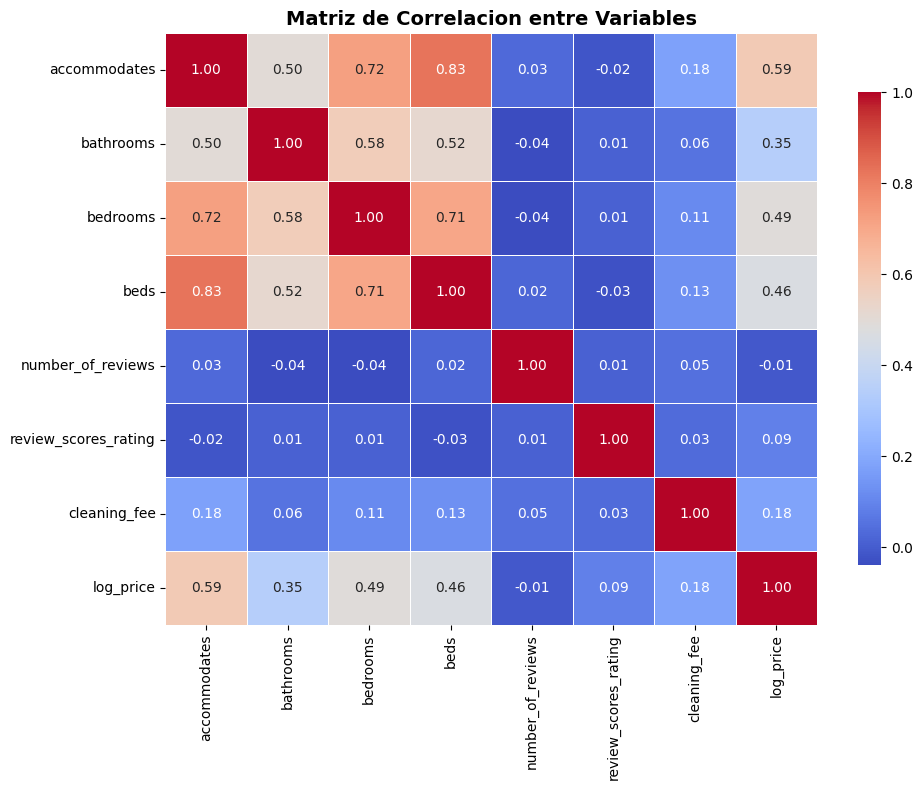

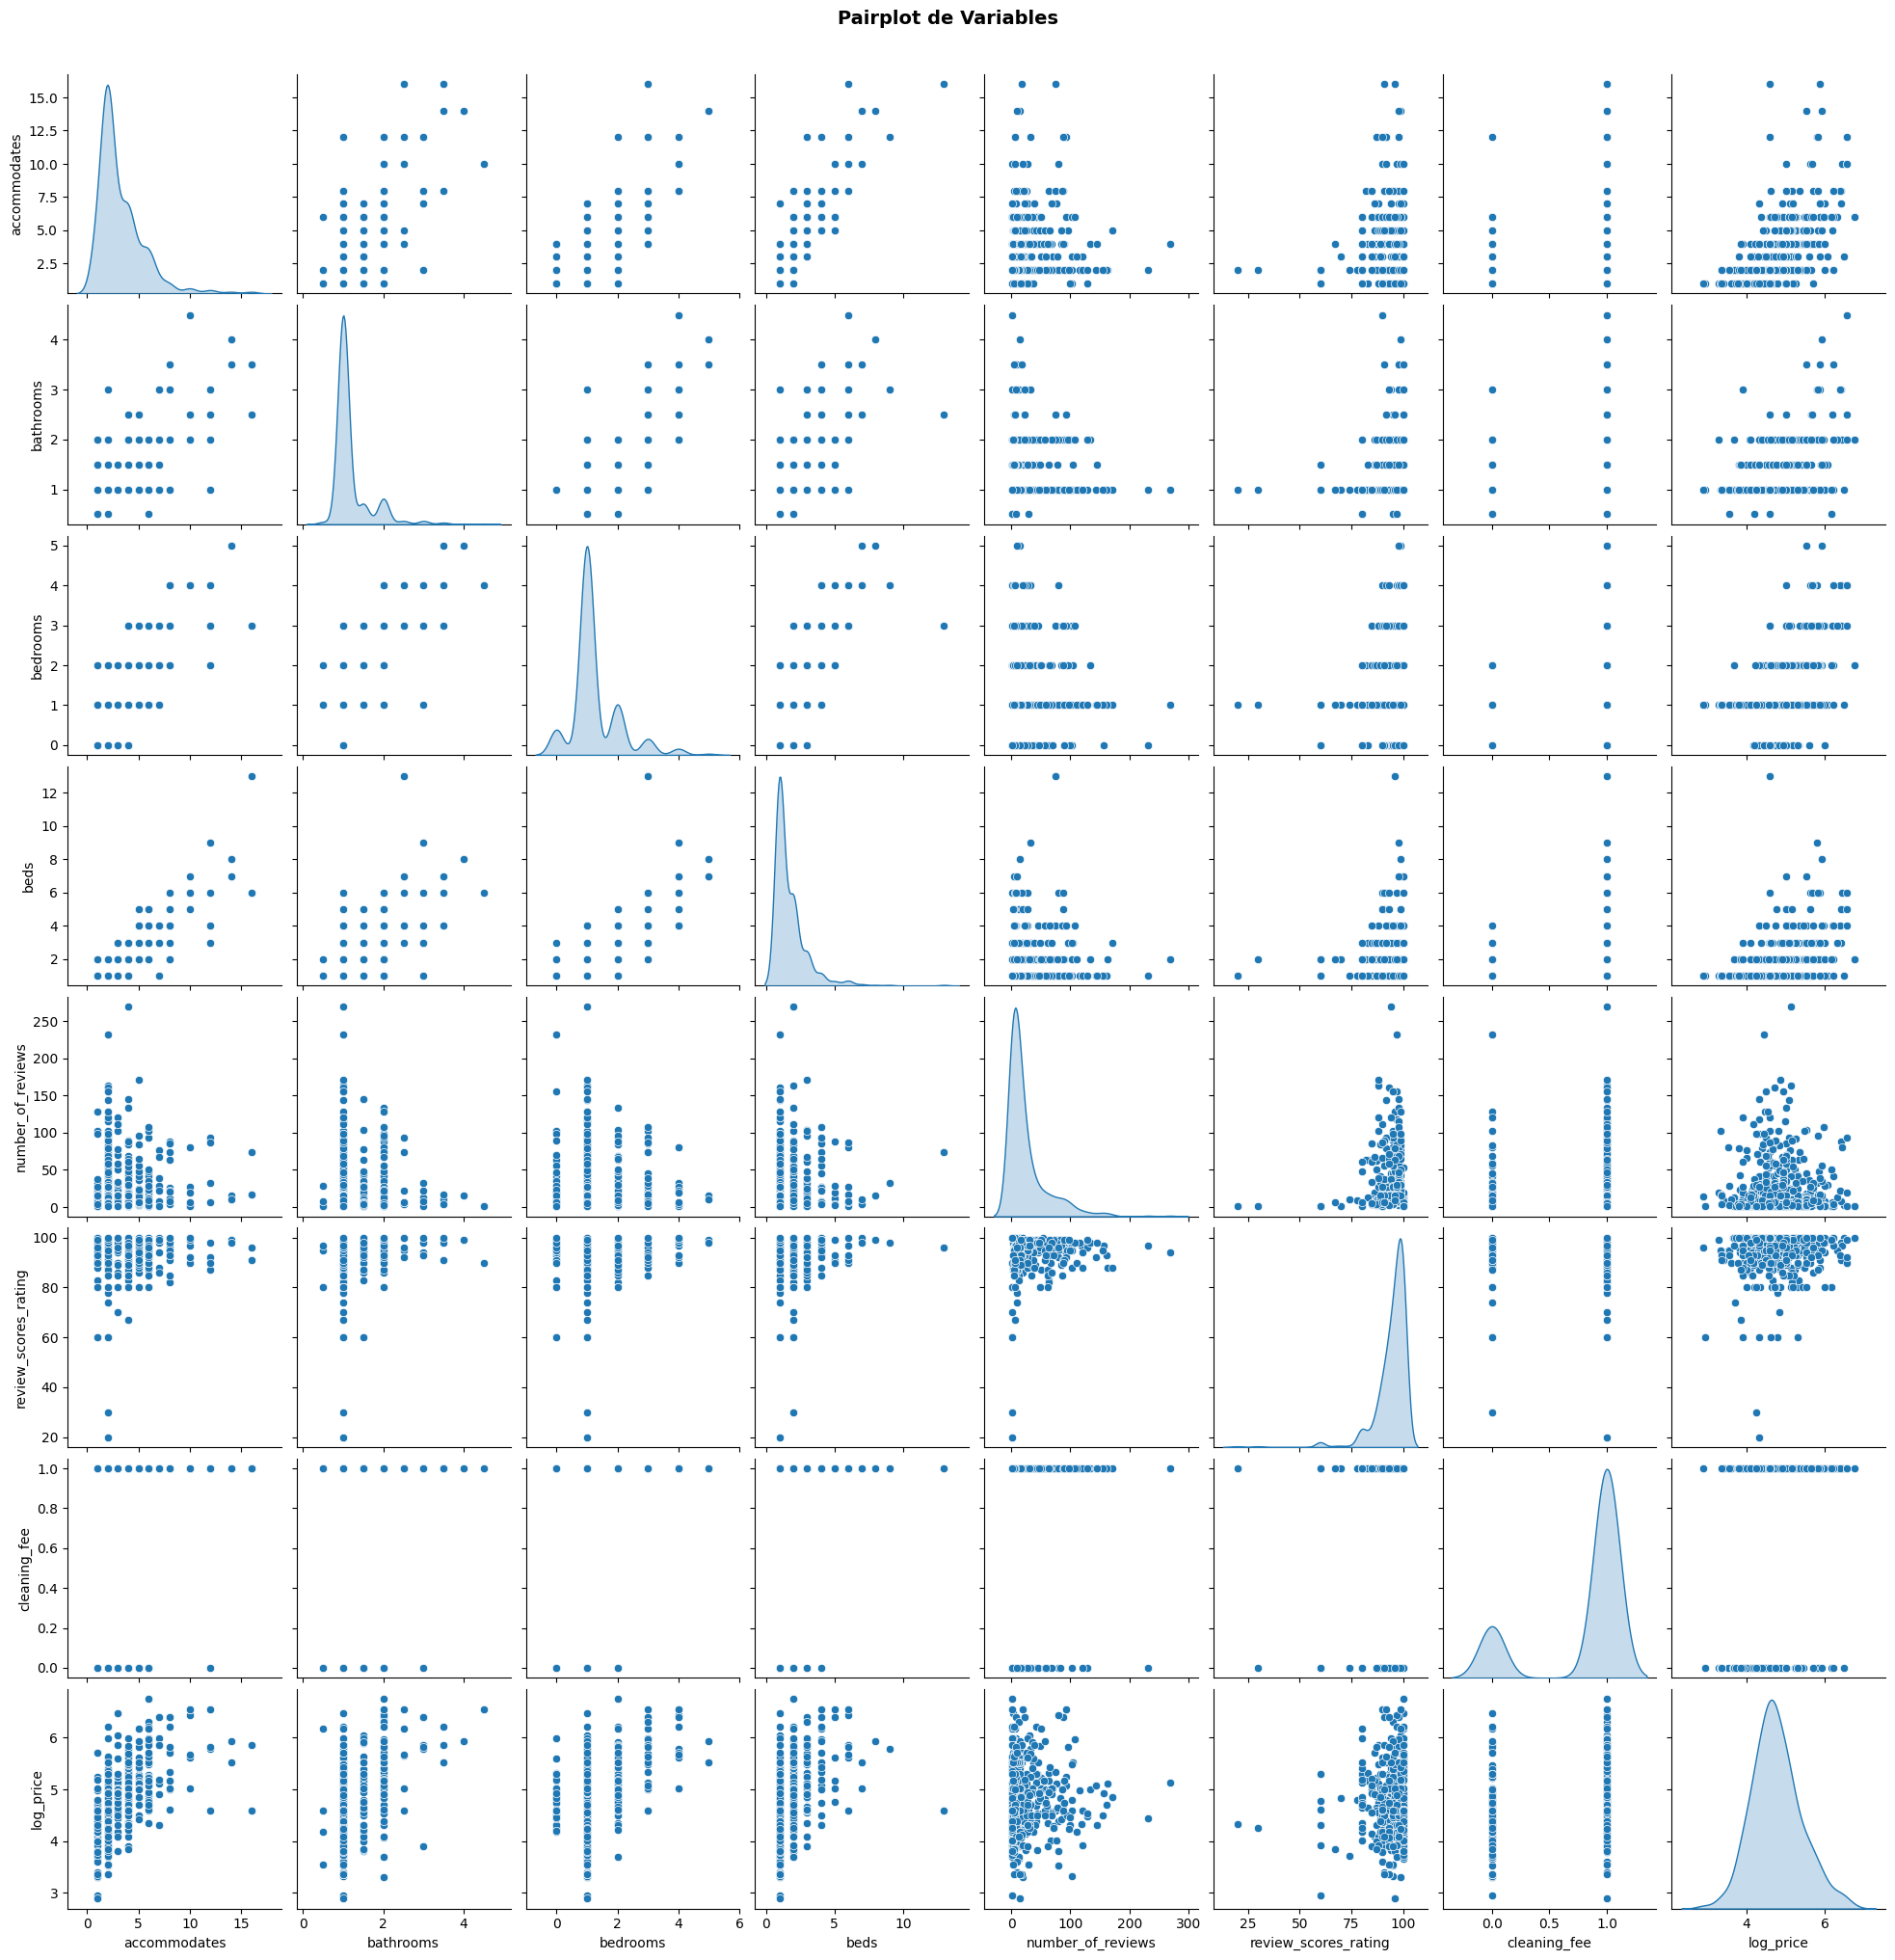

In [ ]:


print("variables dependiente e independientes definidas")

# Variable dependiente: log_price (porque es la que queremos predecir)
# Variables independientes: caracteristicas numericas del anuncio que pueden influir en el precio

variables_independientes = ['accommodates', 'bathrooms', 'bedrooms', 
                            'beds', 'number_of_reviews', 
                            'review_scores_rating', 'cleaning_fee']

X = df[variables_independientes]
y = df['log_price']

print(f"Variable dependiente (y): log_price")
print(f"Variables independientes (X): {variables_independientes}")

print("analisis exploratorio de datos")

# Matriz de correlacion
correlacion = df[variables_independientes + ['log_price']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlacion, annot=True, cmap="coolwarm", fmt=".2f", 
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Matriz de Correlacion entre Variables", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("matriz_correlacion.png", dpi=150)
plt.show()

# Pairplot 
sample = df[variables_independientes + ['log_price']].sample(n=500, random_state=42)
sns.pairplot(sample, diag_kind="kde")
plt.suptitle("Pairplot de Variables", fontsize=14, fontweight="bold", y=1.02)
plt.savefig("pairplot.png", dpi=150)
plt.show()


In [ ]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba: {X_test.shape[0]} muestras")

print("analisis de multicolinealidad con VIF")

X_with_const = add_constant(X_train)
vif_data = pd.DataFrame()
vif_data["Variable"] = X_with_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i) 
                    for i in range(X_with_const.shape[1])]
print(vif_data)

# Si alguna variable tiene VIF > 10, hay multicolinealidad alta
# En este caso bedrooms y beds suelen estar correlacionadas
# Verificamos y si es necesario eliminamos una
if vif_data[vif_data["Variable"] != "const"]["VIF"].max() > 10:
    print("\nSe detecta multicolinealidad alta. Eliminando 'beds'...")
    X = X.drop(columns=["beds"])
    variables_independientes.remove("beds")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    #  recalcular vif
    X_with_const = add_constant(X_train)
    vif_data = pd.DataFrame()
    vif_data["Variable"] = X_with_const.columns
    vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i) 
                        for i in range(X_with_const.shape[1])]
    print(vif_data)

Entrenamiento: 45584 muestras
Prueba: 11397 muestras
analisis de multicolinealidad con VIF
               Variable         VIF
0                 const  152.234585
1          accommodates    3.668749
2             bathrooms    1.573029
3              bedrooms    2.541877
4                  beds    3.517885
5     number_of_reviews    1.012042
6  review_scores_rating    1.004371
7          cleaning_fee    1.036813


In [5]:
print("modelo de regresion lineal multiple con variables independientes")
modelo = LinearRegression()
modelo.fit(X_train, y_train)

print("\nCoeficientes del modelo:")
for var, coef in zip(variables_independientes, modelo.coef_):
    print(f"  {var}: {coef:.6f}")
print(f"  Intercepto: {modelo.intercept_:.6f}")

print("evaluacion del modelo con R² y R² ajustado")

y_train_pred = modelo.predict(X_train)
y_test_pred = modelo.predict(X_test)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

# R² ajustado
n_train = len(y_train)
k = X_train.shape[1]
r2_adj_train = 1 - ((1 - r2_train) * (n_train - 1) / (n_train - k - 1))

n_test = len(y_test)
r2_adj_test = 1 - ((1 - r2_test) * (n_test - 1) / (n_test - k - 1))

print(f"R² (entrenamiento): {r2_train:.4f}")
print(f"R² ajustado (entrenamiento): {r2_adj_train:.4f}")
print(f"R² (prueba): {r2_test:.4f}")
print(f"R² ajustado (prueba): {r2_adj_test:.4f}")

if r2_test > 0.5:
    print("\nEl modelo tiene una capacidad predictiva aceptable.")
else:
    print("\nEl modelo explica menos del 50% de la variabilidad. "
          "Se podrian incluir mas variables para mejorarlo.")

modelo de regresion lineal multiple con variables independientes

Coeficientes del modelo:
  accommodates: 0.174138
  bathrooms: 0.057081
  bedrooms: 0.116115
  beds: -0.068109
  number_of_reviews: -0.000348
  review_scores_rating: 0.007943
  cleaning_fee: 0.129695
  Intercepto: 3.252687
evaluacion del modelo con R² y R² ajustado
R² (entrenamiento): 0.3797
R² ajustado (entrenamiento): 0.3796
R² (prueba): 0.3607
R² ajustado (prueba): 0.3604

El modelo explica menos del 50% de la variabilidad. Se podrian incluir mas variables para mejorarlo.


In [ ]:
print("predicciones vs valores reales en el conjunto de prueba")

resultados = pd.DataFrame({
    "Real": y_test.values,
    "Predicho": y_test_pred,
    "Diferencia": y_test.values - y_test_pred
})
print("\nPrimeras 10 predicciones:")
print(resultados.head(10))

PREDICCIONES vs VALORES REALES

Primeras 10 predicciones:
       Real  Predicho  Diferencia
0  4.779123  4.243855    0.535269
1  5.521461  5.292256    0.229205
2  4.595120  4.672890   -0.077770
3  4.744932  4.519388    0.225545
4  3.891820  4.345822   -0.454002
5  5.225747  4.508995    0.716752
6  3.295837  4.368708   -1.072871
7  5.700444  4.792370    0.908074
8  4.779123  4.498238    0.280886
9  4.488636  4.582775   -0.094139


In [7]:

print("error cuadratico medio (MSE) y raiz del error cuadratico medio (RMSE)")

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)

print(f"MSE (entrenamiento): {mse_train:.6f}")
print(f"MSE (prueba): {mse_test:.6f}")
print(f"RMSE (prueba): {rmse_test:.6f}")
print(f"\nEn promedio, las predicciones se desvian ${np.exp(rmse_test):.2f} "
      f"del precio real (en escala original).")

error cuadratico medio (MSE) y raiz del error cuadratico medio (RMSE)
MSE (entrenamiento): 0.278148
MSE (prueba): 0.281467
RMSE (prueba): 0.530535

En promedio, las predicciones se desvian $1.70 del precio real (en escala original).


visualizaciones con matplotlib y seaborn


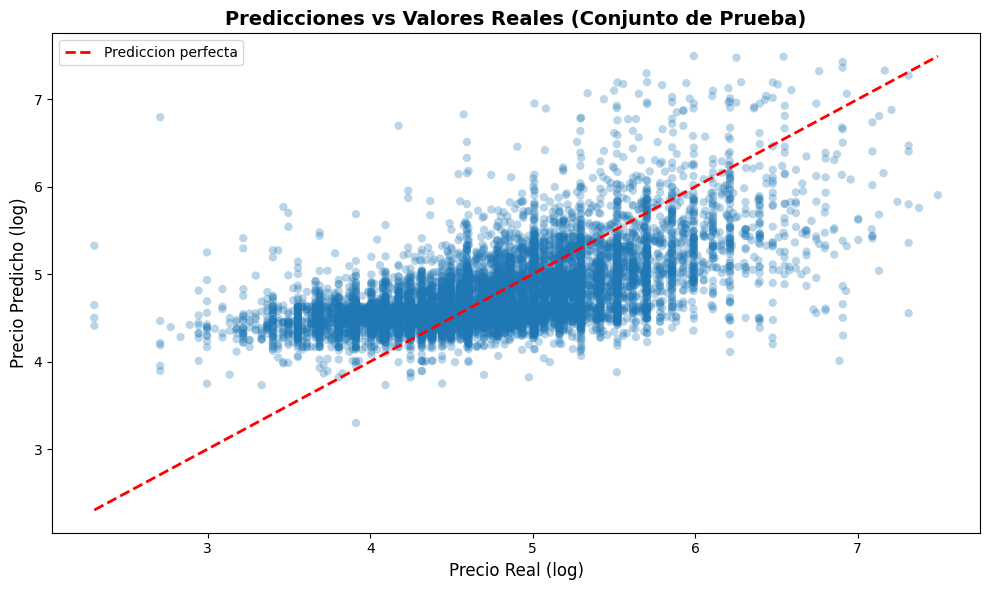

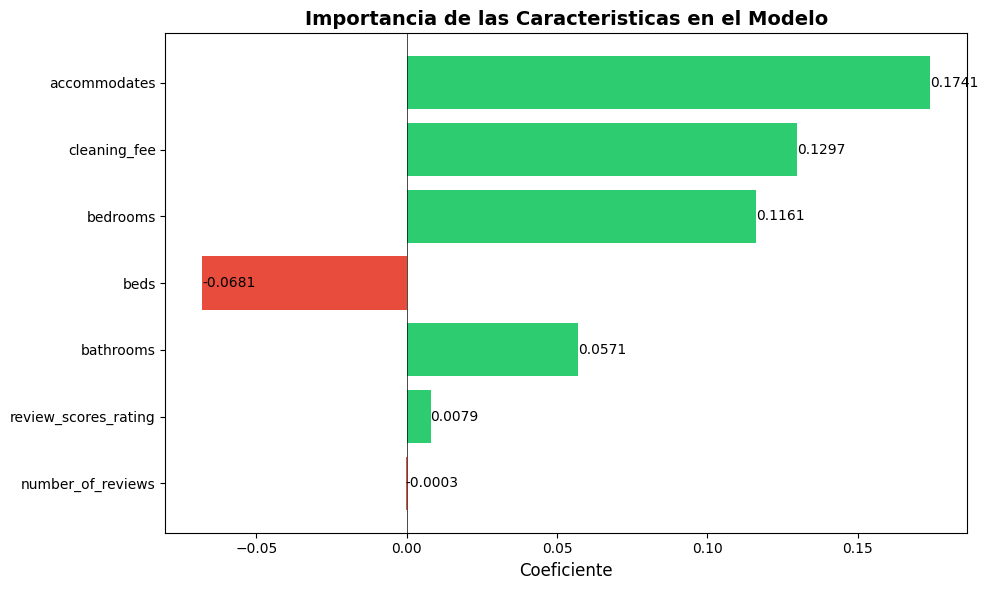

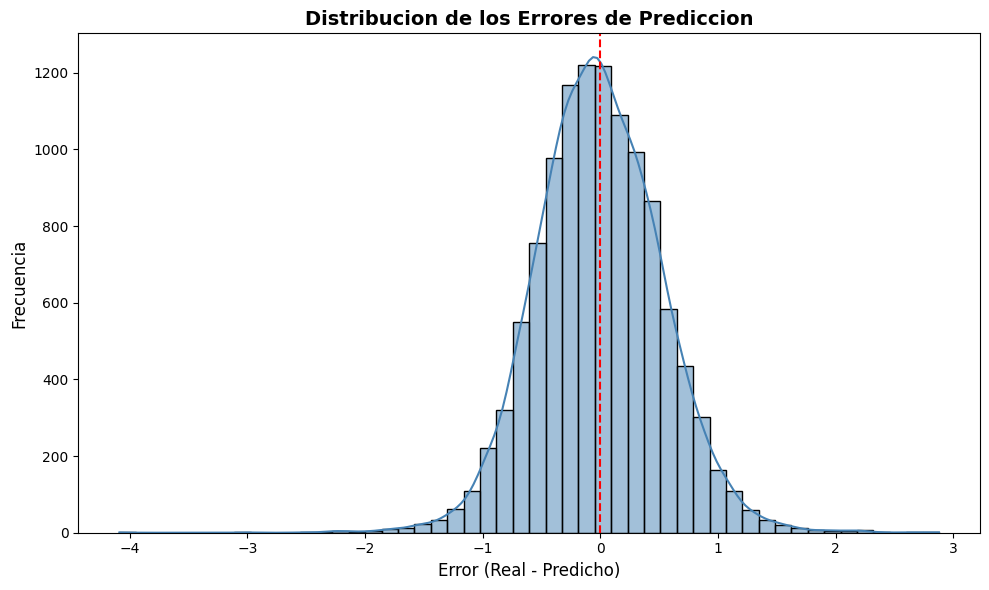

In [ ]:
print("visualizaciones con matplotlib y seaborn")

# Grafico 1 de predicciones vs valores reales
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, alpha=0.3, edgecolors="none")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         "r--", lw=2, label="Prediccion perfecta")
plt.xlabel("Precio Real (log)", fontsize=12)
plt.ylabel("Precio Predicho (log)", fontsize=12)
plt.title("Predicciones vs Valores Reales (Conjunto de Prueba)", 
          fontsize=14, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.savefig("predicciones_vs_reales.png", dpi=150)
plt.show()

# Grafico 2 de importancia de las caracteristicas (coeficientes)
plt.figure(figsize=(10, 6))
coeficientes = pd.DataFrame({
    "Variable": variables_independientes,
    "Coeficiente": modelo.coef_
})
coeficientes = coeficientes.sort_values("Coeficiente", key=abs, ascending=True)

colores = ["#e74c3c" if c < 0 else "#2ecc71" for c in coeficientes["Coeficiente"]]
plt.barh(coeficientes["Variable"], coeficientes["Coeficiente"], color=colores)
plt.axvline(x=0, color="black", linestyle="-", linewidth=0.5)
plt.xlabel("Coeficiente", fontsize=12)
plt.title("Importancia de las Caracteristicas en el Modelo", 
          fontsize=14, fontweight="bold")
for i, v in enumerate(coeficientes["Coeficiente"]):
    plt.text(v, i, f"{v:.4f}", va="center", fontsize=10)
plt.tight_layout()
plt.savefig("importancia_caracteristicas.png", dpi=150)
plt.show()

# Grafico 3 de distribucion de los errores
errores = y_test - y_test_pred
plt.figure(figsize=(10, 6))
sns.histplot(errores, bins=50, kde=True, color="steelblue")
plt.axvline(x=0, color="red", linestyle="--", linewidth=1.5)
plt.xlabel("Error (Real - Predicho)", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.title("Distribucion de los Errores de Prediccion", 
          fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("distribucion_errores.png", dpi=150)
plt.show()